In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [ ]:
ls  /kaggle/input/cat-and-dog/training_set/training_set

cats/  dogs/


In [ ]:
import tensorflow as tf
import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data = tf.keras.utils.image_dataset_from_directory('/kaggle/input/cat-and-dog/training_set/training_set')

Found 8005 files belonging to 2 classes.


In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

In [ ]:
len(batch)

2

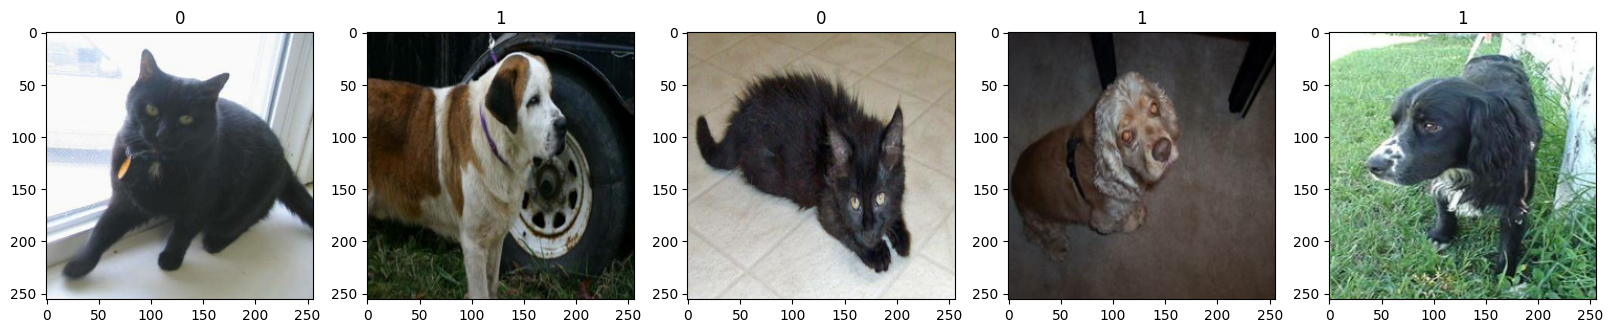

In [ ]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
data = data.map(lambda x,y: (x/255, y))

In [ ]:
data.as_numpy_iterator().next()


(array([[[[0.42435035, 0.45180136, 0.42042878],
          [0.3988217 , 0.4262727 , 0.39490014],
          [0.45713228, 0.48458326, 0.4532107 ],
          ...,
          [0.39044696, 0.4335842 , 0.37083912],
          [0.421201  , 0.4696266 , 0.4083194 ],
          [0.37930757, 0.43420953, 0.3743536 ]],
 
         [[0.4542531 , 0.4817041 , 0.45033154],
          [0.4402711 , 0.4677221 , 0.43634954],
          [0.3962571 , 0.42370808, 0.39233553],
          ...,
          [0.3941037 , 0.42745236, 0.36797014],
          [0.3662415 , 0.41389775, 0.34889317],
          [0.33952206, 0.3959726 , 0.32690093]],
 
         [[0.37212777, 0.39957875, 0.3682062 ],
          [0.4116773 , 0.43912828, 0.40775573],
          [0.39779308, 0.42524406, 0.39387152],
          ...,
          [0.3982415 , 0.4311306 , 0.36927396],
          [0.34499344, 0.39264968, 0.32197595],
          [0.32242647, 0.37893668, 0.29846814]],
 
         ...,
 
         [[0.57271016, 0.5358995 , 0.48162562],
          [0.51453

In [ ]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% tes

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [ ]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                 input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 4
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Fully Connected
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,200,833 (65.62 MB)

 Trainable params: 17,199,873 (65.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
logdir = 'logs'

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 51s 186ms/step - accuracy: 0.5259 - loss: 5.0682 - val_accuracy: 0.4731 - val_loss: 0.9717
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.5177 - loss: 1.2887 - val_accuracy: 0.5188 - val_loss: 0.6983
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.5336 - loss: 0.7564 - val_accuracy: 0.5675 - val_loss: 0.6843
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.5529 - loss: 0.7137 - val_accuracy: 0.6087 - val_loss: 0.6730
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 210ms/step - accuracy: 0.5664 - loss: 0.6867 - val_accuracy: 0.6488 - val_loss: 0.6403
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 211ms/step - accuracy: 0.5977 - loss: 0.6682 - val_accuracy: 0.6025 - val_loss: 0.6399
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 211ms/step - accuracy: 0.6268 - loss: 0.6422 - val_accuracy: 0.6644 - val_loss: 0.6007
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.6621 - loss: 0

In [ ]:
hist2 = model.fit(
    train,
    epochs=10,
    validation_data=val,
    callbacks=[tensorboard_callback]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.9495 - loss: 0.1297 - val_accuracy: 0.8012 - val_loss: 0.8539
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.9609 - loss: 0.1099 - val_accuracy: 0.7631 - val_loss: 0.9569
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 209ms/step - accuracy: 0.9671 - loss: 0.0926 - val_accuracy: 0.8512 - val_loss: 0.6006
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.9718 - loss: 0.0736 - val_accuracy: 0.8487 - val_loss: 0.5974
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.9745 - loss: 0.0737 - val_accuracy: 0.7237 - val_loss: 1.1505
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step - accuracy: 0.9786 - loss: 0.0644 - val_accuracy: 0.8263 - val_loss: 0.8012
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.9827 - loss: 0.0517 - val_accuracy: 0.7594 - val_loss: 0.8675
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.9805 - loss: 0

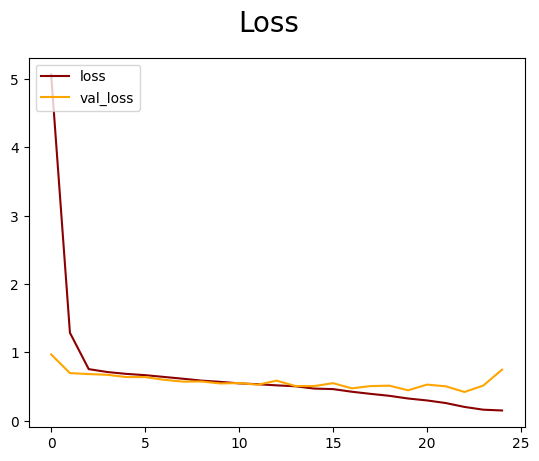

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

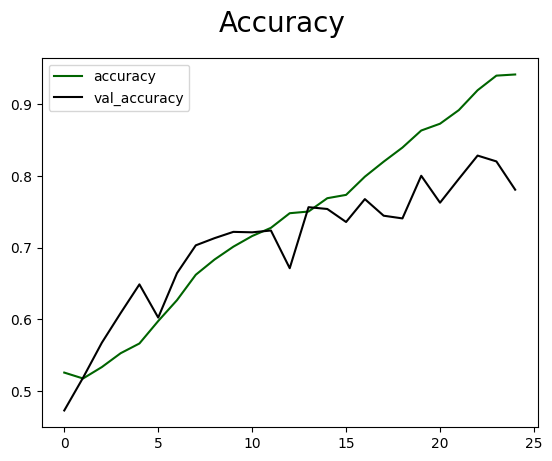

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
import cv2

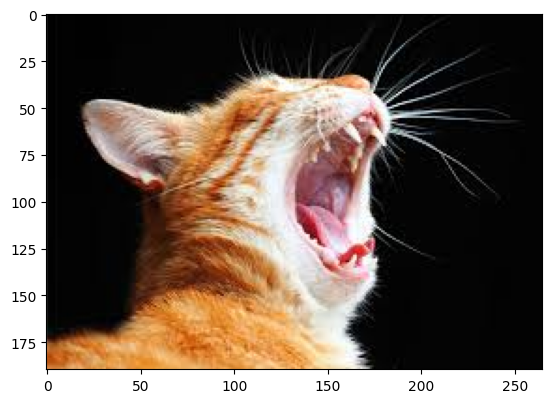

In [ ]:
img = cv2.imread('/content/download (4).jpg')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

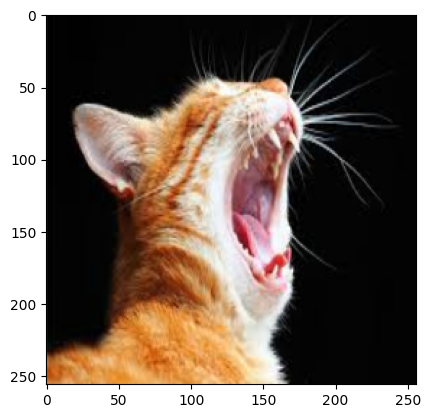

In [ ]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [ ]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
yhat

array([[0.23775366]], dtype=float32)

In [ ]:
if yhat > 0.5:
    print(f'Predicted class is dog')
else:
    print(f'Predicted class is cat')

Predicted class is cat
